Goal: Produce WOE/IV-based features, train classifiers (logistic regression + AdaBoost), evaluate them, and derive a point-based credit score for each borrower.


In [30]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


In [31]:
df = pd.read_csv('credit_risk_dataset.csv')
print(df.head())

   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [33]:
df.shape

(32581, 12)

In [34]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In the age it is 144(max) which is impossible- outlier
Max income = 60 lakh+ that's a heavy outlier
123 years employment = impossible.
In Loan_percent income Some people spend 83% of income on loan, which is very risky yet realistic


Capping means we set an upper (or sometimes lower) limit on a variable so that any values beyond that limit are brought back to the limit. In other words, if we say we cap age at 80, anyone older than 80 is treated as if they were 80. We do this when outliers (like an age of 144) might distort the model. So capping just ensures extreme values don’t overwhelm the patterns the model is learning.

In [35]:
#Apply simple capping to age and employment length
# cap age
df.loc[df['person_age'] > 80, 'person_age'] = 80

# cap employment length
df.loc[df['person_emp_length'] > 40, 'person_emp_length'] = 40


In [36]:
df[['person_age','person_emp_length']].describe()

,person_age,person_emp_length
count,32581.000000,31686.000000
mean,27.725515,4.784416
std,6.233069,4.044171
min,20.000000,0.000000
25%,23.000000,2.000000
50%,26.000000,4.000000
75%,30.000000,7.000000
max,80.000000,40.000000


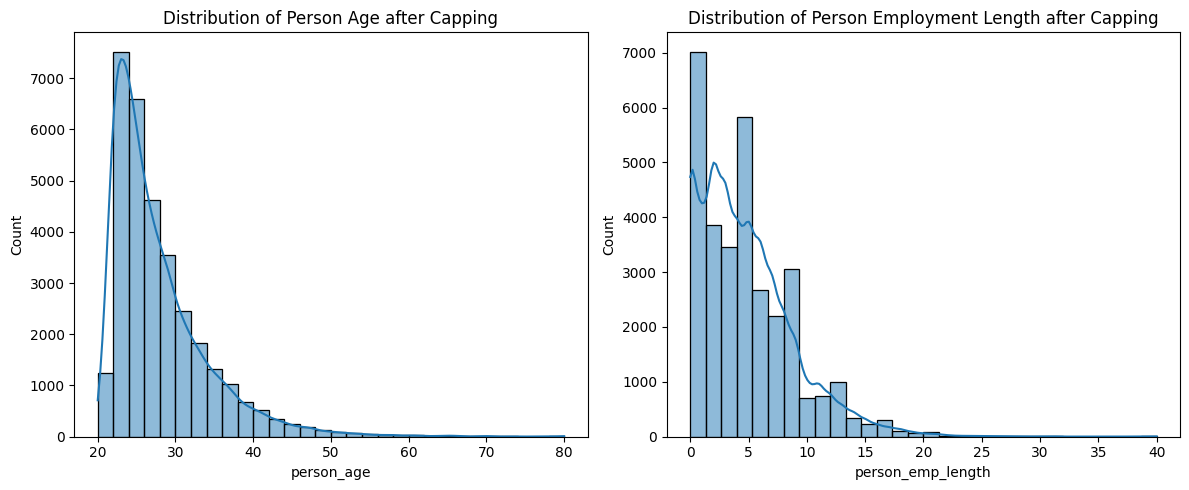

In [37]:
# Visualize the distribution of age and employment length after capping
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['person_age'], bins=30, ax=axes[0], kde=True)
axes[0].set_title('Distribution of Person Age after Capping')   
sns.histplot(df['person_emp_length'], bins=30, ax=axes[1], kde=True)
axes[1].set_title('Distribution of Person Employment Length after Capping')     

plt.tight_layout()
plt.show()  


So,Unrealistic 144 is gone
Distribution now looks natural (young-heavy, long right tail)
The histogram confirms this:
- Most people are between ~20–35
- Few older customers — realistic for loan data

In [38]:
#Handle missing values
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [39]:
#Check the percentage of missing value in the person_emp_length column and loan_int_rate column
total_rows = df.shape[0]
missing_emp_length = df['person_emp_length'].isnull().sum()
missing_int_rate = df['loan_int_rate'].isnull().sum()
print(f"Percentage of missing values in person_emp_length: {missing_emp_length / total_rows * 100:.2f}%")
print(f"Percentage of missing values in loan_int_rate: {missing_int_rate / total_rows* 100:.2f}%")


Percentage of missing values in person_emp_length: 2.75%
Percentage of missing values in loan_int_rate: 9.56%


In [40]:
#Create missing indicator columns
df['emp_length_missing'] = df['person_emp_length'].isna().astype(int)
df['int_rate_missing'] = df['loan_int_rate'].isna().astype(int)

In [41]:
#using median to fill missing values
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
df.isnull().sum()


C:\Users\patel\AppData\Local\Temp\ipykernel_17184\1372230902.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
C:\Users\patel\AppData\Local\Temp\ipykernel_17184\1372230902.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alwa

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
emp_length_missing            0
int_rate_missing              0
dtype: int64

In [42]:
#Save the cleaned data
df.to_csv('credit_risk_cleaned.csv', index=False)


In [43]:
#read the clean dataset
df = pd.read_csv('credit_risk_cleaned.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           32581 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               32581 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
 12  emp_length_missing          32581 non-null  int64  
 13  int_rate_missing            325

In [44]:
#Get the categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']


In [45]:
#Get the numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
print("Numerical Columns:", numerical_cols)

Numerical Columns: ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_cred_hist_length', 'emp_length_missing', 'int_rate_missing']


In [46]:
# Detect categorical columns automatically
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print("Detected categorical columns:", categorical_cols)

# One hot encode
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Verify
df.info()
df.head()

Detected categorical columns: Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_age                   32581 non-null  int64  
 1   person_income                32581 non-null  int64  
 2   person_emp_length            32581 non-null  float64
 3   loan_amnt                    32581 non-null  int64  
 4   loan_int_rate                32581 non-null  float64
 5   loan_status                  32581 non-null  int64  
 6   loan_percent_income          32581 non-null  float64
 7   cb_person_cred_hist_length   32581 non-null  int64  
 8   emp_length_missing           32581 non-null  int64  
 9   int_rate_missing             32581 non-null  int64  
 10  person_home_ownership_OTHER  32581 non-n

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,emp_length_missing,int_rate_missing,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,40.0,35000,16.02,1,0.59,3,0,0,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,0,0,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,0,0,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,0,0,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,0,0,...,True,False,False,False,True,False,False,False,False,True


In [47]:
#separate features and target variable
X = df.drop('loan_status', axis=1)
y = df['loan_status']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (32581, 24)
y shape: (32581,)


In [48]:
#Train the model train test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
#Standard scaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("Train X:", X_train.shape)
print("Test X:", X_test.shape)
print("Train y:", y_train.shape)
print("Test y:", y_test.shape)

Train X: (26064, 24)
Test X: (6517, 24)
Train y: (26064,)
Test y: (6517,)


In [49]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# # Fit on training data, transform both
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# print("Scaled train shape:", X_train_scaled.shape)
# print("Scaled test shape:", X_test_scaled.shape)


In [50]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [51]:
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (26064, 24)
Scaled test shape: (6517, 24)


In [52]:
#Train a logistic regression model
from sklearn.linear_model import LogisticRegression
# Create model
log_model = LogisticRegression(max_iter=1000)
# Train model
log_model.fit(X_train_scaled, y_train)
print("Model trained successfully!")


Model trained successfully!


In [53]:
#Evaluate the model 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
y_pred = log_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)   
f1 = f1_score(y_test, y_pred)
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)


Accuracy: 0.8665
Precision: 0.7644
Recall: 0.5612
F1 Score: 0.6472
Confusion Matrix:
[[4849  246]
 [ 624  798]]
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.76      0.56      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.78      6517
weighted avg       0.86      0.87      0.86      6517



In [54]:
#Threshold tuning uses y_probs BEFORE creating it
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]
thresholds = [0.5, 0.45, 0.4, 0.35]
for thresh in thresholds:
    y_pred_thresh = (y_probs >= thresh).astype(int)

    print(f"Threshold: {thresh}")
    print(f"Recall(defaulters): {recall_score(y_test, y_pred_thresh):.3f}   Precision: {precision_score(y_test, y_pred_thresh):.3f}")
    print(classification_report(y_test, y_pred_thresh))
    

Threshold: 0.5
Recall(defaulters): 0.561   Precision: 0.764
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      5095
           1       0.76      0.56      0.65      1422

    accuracy                           0.87      6517
   macro avg       0.83      0.76      0.78      6517
weighted avg       0.86      0.87      0.86      6517

Threshold: 0.45
Recall(defaulters): 0.605   Precision: 0.737
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      5095
           1       0.74      0.60      0.66      1422

    accuracy                           0.87      6517
   macro avg       0.82      0.77      0.79      6517
weighted avg       0.86      0.87      0.86      6517

Threshold: 0.4
Recall(defaulters): 0.648   Precision: 0.700
              precision    recall  f1-score   support

           0       0.90      0.92      0.91      5095
           1       0.70      0.65      0.67      1422

 

In credit risk,False Negatives matter MOST.That’s:624 risky customers slipped through
Out of 1422 defaulters: We caught 798 and we missed 624,That’s:Almost HALF risky customers got loans.This is unacceptable for production.

Recall is only 56 % which means of ALL real defaulters we  caught only 56%.

In [55]:
#Since the recall is low, we can try to improve it by tuning the model hyperparameters or using a different model.
# Using class imbalace handling techniques like SMOTE or adjusting class weights can also help improve recall.
log_model_bal = LogisticRegression(max_iter=1000, class_weight='balanced')

log_model_bal.fit(X_train_scaled, y_train)

y_pred_bal = log_model_bal.predict(X_test_scaled)

print(classification_report(y_test, y_pred_bal))
print(confusion_matrix(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5095
           1       0.55      0.78      0.65      1422

    accuracy                           0.81      6517
   macro avg       0.74      0.80      0.76      6517
weighted avg       0.85      0.81      0.83      6517

[[4198  897]
 [ 309 1113]]


Out of 1422 defaulters:Caught: 1113,Missed: 309
Only ~22% escape now.Earlier ~44%.



In [57]:
log_model_bal.fit(X_train, y_train)
y_pred_rf = log_model_bal.predict(X_test)

In [58]:
#Checking different probability thresholds for better recall
y_probs = log_model_bal.predict_proba(X_test_scaled)[:, 1]
thresholds = [0.5, 0.45, 0.4, 0.35]
for thresh in thresholds:
    y_pred_thresh = (y_probs >= thresh).astype(int)

    print(f"Threshold: {thresh}")
    print(f"Recall(defaulters): {recall_score(y_test, y_pred_thresh):.3f}   Precision: {precision_score(y_test, y_pred_thresh):.3f}")
    print(classification_report(y_test, y_pred_thresh))

Threshold: 0.5
Recall(defaulters): 0.783   Precision: 0.554
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      5095
           1       0.55      0.78      0.65      1422

    accuracy                           0.81      6517
   macro avg       0.74      0.80      0.76      6517
weighted avg       0.85      0.81      0.83      6517

Threshold: 0.45
Recall(defaulters): 0.803   Precision: 0.513
              precision    recall  f1-score   support

           0       0.93      0.79      0.85      5095
           1       0.51      0.80      0.63      1422

    accuracy                           0.79      6517
   macro avg       0.72      0.80      0.74      6517
weighted avg       0.84      0.79      0.80      6517

Threshold: 0.4
Recall(defaulters): 0.832   Precision: 0.478
              precision    recall  f1-score   support

           0       0.94      0.75      0.83      5095
           1       0.48      0.83      0.61      1422

 

              precision    recall  f1-score   support

           0       0.94      0.75      0.83      5095
           1       0.48      0.83      0.61      1422

    accuracy                           0.76      6517
   macro avg       0.71      0.79      0.72      6517
weighted avg       0.84      0.76      0.78      6517

[[3801 1294]
 [ 239 1183]]


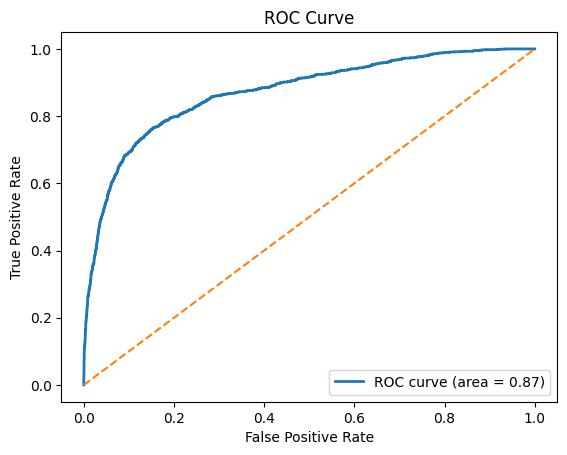

In [59]:
#Probability thresholing for 0.4 for economic reason
y_probs = log_model_bal.predict_proba(X_test_scaled)[:, 1]
y_pred_thresh = (y_probs >= 0.4).astype(int)
print(classification_report(y_test, y_pred_thresh))
print(confusion_matrix(y_test, y_pred_thresh))

# #Visualise roc and auc curve
# from sklearn.metrics import roc_curve, auc
# fpr, tpr, thresholds = roc_curve(y_test, y_probs)
# roc_auc = auc(fpr, tpr)
# plt.figure()
# plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
# plt.xlim([0.0, 1.0])    
# plt.ylim([0.0, 1.05])
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic')
# plt.legend(loc="lower right")
# plt.show()

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()



                       Feature  Coefficient  Abs_Coefficient
5          loan_percent_income     1.356175         1.356175
19                loan_grade_D     0.809172         0.809172
3                    loan_amnt    -0.633259         0.633259
20                loan_grade_E     0.489213         0.489213
10   person_home_ownership_OWN    -0.445009         0.445009
16         loan_intent_VENTURE    -0.394656         0.394656
11  person_home_ownership_RENT     0.342448         0.342448
21                loan_grade_F     0.286750         0.286750
22                loan_grade_G     0.264061         0.264061
12       loan_intent_EDUCATION    -0.244611         0.244611
18                loan_grade_C     0.207241         0.207241
4                loan_int_rate     0.199464         0.199464
15        loan_intent_PERSONAL    -0.147791         0.147791
17                loan_grade_B     0.139436         0.139436
7           emp_length_missing     0.129320         0.129320


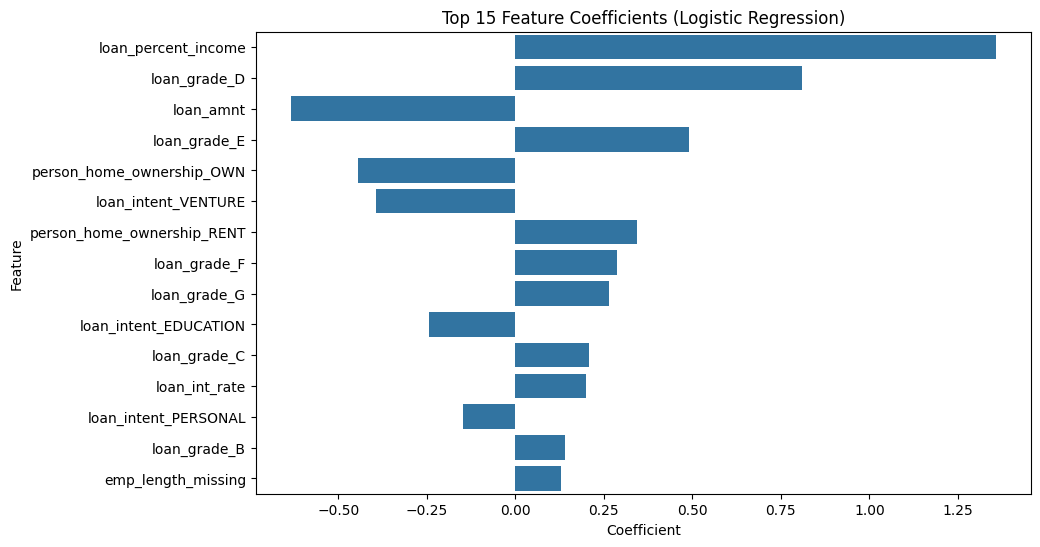

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get coefficients from the balanced logistic model
coefficients = log_model_bal.coef_[0]

# Feature names
feature_names = X.columns

# Create dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Add absolute value for ranking
importance_df['Abs_Coefficient'] = importance_df['Coefficient'].abs()

# Sort by absolute importance
importance_df = importance_df.sort_values(by='Abs_Coefficient', ascending=False)

# Show top 15 features
top_features = importance_df.head(15)

print(top_features)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Coefficient', y='Feature', data=top_features)
plt.title('Top 15 Feature Coefficients (Logistic Regression)')
plt.show()


Feature importance analysis showed loan-to-income ratio as the strongest driver of default, followed by loan grade and interest rate. Renters and customers with missing employment history exhibited higher risk, while home ownership and education loans reduced default probability. These patterns align with domain expectations, validating model behavior.

*Sign (+ / −) → direction of risk
Magnitude (absolute value) → strength of influence*

*Positive coefficient:Increases probability of default and
Negative coefficient : Decreases probability of default (safer)*

The Logistic Regression model shows that `loan_percent_income` is the strongest predictor of default — customers spending a higher portion of income on loans are much more likely to default. Poor loan grades (D–G), higher interest rates, renting a home, and missing employment history also increase risk.
On the other hand, home ownership, education loans, and higher loan amounts are associated with lower default probability, likely due to stricter approval for these cases.
Overall, the feature importance aligns well with real-world credit risk behavior, validating the model’s reliability.

In [64]:
#Random forest model to improve performance
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest model trained successfully!")


Random Forest model trained successfully!


In [65]:
#Fiting the random forest model and evaluating it
y_pred_rf = rf_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.92      0.99      0.96      5095
           1       0.96      0.71      0.82      1422

    accuracy                           0.93      6517
   macro avg       0.94      0.85      0.89      6517
weighted avg       0.93      0.93      0.93      6517

[[5054   41]
 [ 414 1008]]


By Feature importance in Random Forest it tells Which variables does the model USE MOST to make decisions?

Logistic importance tells direction of risk.
Random Forest importance tells strength of usage.We compare both to validate features.

                        Feature  Importance
5           loan_percent_income    0.199946
1                 person_income    0.159760
4                 loan_int_rate    0.138048
3                     loan_amnt    0.084114
19                 loan_grade_D    0.059976
11   person_home_ownership_RENT    0.057271
2             person_emp_length    0.054104
0                    person_age    0.053165
6    cb_person_cred_hist_length    0.041323
23  cb_person_default_on_file_Y    0.017319
10    person_home_ownership_OWN    0.016668
18                 loan_grade_C    0.015326
20                 loan_grade_E    0.015071
13  loan_intent_HOMEIMPROVEMENT    0.014828
16          loan_intent_VENTURE    0.014371


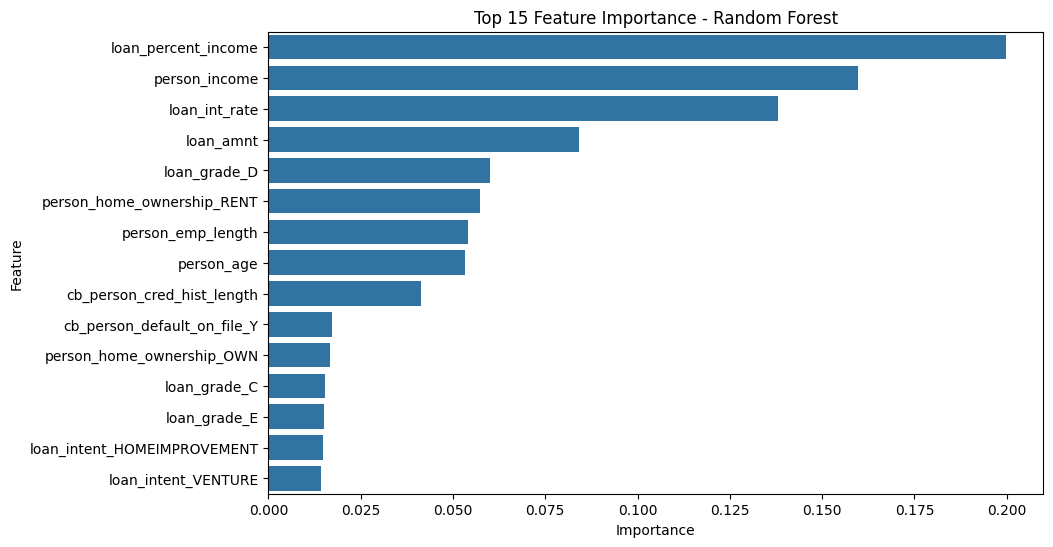

In [ ]:

# Get feature importance from Random Forest
rf_importance = rf_model.feature_importances_

# Create dataframe
rf_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_importance
})

# Sort by importance
rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

# Show top 15
top_rf_features = rf_importance_df.head(15)
print(top_rf_features)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=top_rf_features)
plt.title('Top 15 Feature Importance - Random Forest')
plt.show()


Why NOT Random Forest used to calculate the PD (usually), beacause it is:
- Non-linear
- Black box
- Unstable over time
- Hard to explain  
- Regulators dislike it

So RF is used mainly as
- Benchmark model
- Performance comparison

Not for final PD.

In [66]:
#Calculating Probability of Default
pd_default = log_model_bal.predict_proba(X_test_scaled)[:,1]


In [75]:
# Add probability of default for test rows back to the main dataframe
df['prob_default'] = np.nan
df.loc[y_test.index, 'prob_default'] = pd_default

# Optionally save
df.to_csv('credit_risk_with_pd.csv', index=False)
print("Added prob_default and saved to credit_risk_with_pd.csv")

Added prob_default and saved to credit_risk_with_pd.csv


In [81]:
df.columns

Index(['person_age', 'person_income', 'person_emp_length', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_cred_hist_length', 'emp_length_missing', 'int_rate_missing',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B',
       'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F',
       'loan_grade_G', 'cb_person_default_on_file_Y', 'prob_default'],
      dtype='object')

In [82]:
grade_cols = [
    "loan_grade_B",
    "loan_grade_C",
    "loan_grade_D",
    "loan_grade_E",
    "loan_grade_F",
    "loan_grade_G"
]

def recover_grade(row):
    for col in grade_cols:
        if row[col] == 1:
            return col.split("_")[-1]
    return "A"   # if none are 1, it's A

df["loan_grade_recovered"] = df.apply(recover_grade, axis=1)

df[["loan_grade_recovered"]].head()


,loan_grade_recovered
0,D
1,B
2,C
3,C
4,C


In [83]:
grade_order = ["A","B","C","D","E","F","G"]

df_pd = df.dropna(subset=["prob_default"]).copy()

df_pd["Grade_Band"] = pd.Categorical(
    df_pd["loan_grade_recovered"],
    categories=grade_order,
    ordered=True
)

df_pd[["loan_grade_recovered","Grade_Band"]].head()


,loan_grade_recovered,Grade_Band
13,E,E
22,D,D
33,C,C
37,D,D
41,B,B


In [84]:
df_pd["PD_SubBand"] = df_pd.groupby("Grade_Band")["prob_default"].transform(
    lambda x: pd.qcut(x, q=2, labels=["Low_PD","High_PD"])
)


C:\Users\patel\AppData\Local\Temp\ipykernel_17184\1879824360.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_pd["PD_SubBand"] = df_pd.groupby("Grade_Band")["prob_default"].transform(


In [86]:
df_pd["Final_Risk_Band"] = df_pd["Grade_Band"].astype(str) + "_" + df_pd["PD_SubBand"].astype(str)

df_pd[["loan_grade_recovered","prob_default","Final_Risk_Band"]].head()


,loan_grade_recovered,prob_default,Final_Risk_Band
13,E,0.80,E_High_PD
22,D,0.82,D_High_PD
33,C,0.06,C_Low_PD
37,D,0.96,D_High_PD
41,B,0.76,B_High_PD


In [87]:
import joblib

# Save model
joblib.dump(log_model_bal, "credit_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save feature columns (very important!)
joblib.dump(list(X.columns), "model_features.pkl")

print("Model, scaler, and feature list saved.")


Model, scaler, and feature list saved.
